# 00 — Overview del sistema hospitalario

Este notebook explica la arquitectura completa de **laSalle Health Center**: servicios Docker, almacenamiento, flujo de datos, modelos de IA, dashboard, monitorización y automatización.

Úsalo para abrir la defensa del proyecto y explicar que no es un script aislado, sino una infraestructura containerizada.

In [3]:

from pathlib import Path
import json
import os
import subprocess
import textwrap
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto localizando docker-compose.yml."""
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "docker-compose.yml").exists():
            return candidate
    # Si el notebook se ejecuta desde notebooks/ antes de abrir el repo correctamente.
    return start


ROOT = find_project_root()
print(f"ROOT = {ROOT}")


def read_json(path: Path, default=None):
    path = Path(path)
    if not path.exists():
        print(f"[missing] {path}")
        return default
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def read_env(path: Path) -> dict:
    env = {}
    path = Path(path)
    if not path.exists():
        return env
    for raw in path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        k, v = line.split("=", 1)
        env[k.strip()] = v.strip().strip('"').strip("'")
    return env


def run_cmd(cmd: str, timeout: int = 60) -> str:
    """Ejecuta un comando shell y devuelve stdout/stderr como texto."""
    print(f"$ {cmd}")
    try:
        result = subprocess.run(
            cmd,
            shell=True,
            cwd=ROOT,
            text=True,
            capture_output=True,
            timeout=timeout,
        )
        if result.stdout:
            print(result.stdout)
        if result.stderr:
            print(result.stderr)
        print(f"exit_code={result.returncode}")
        return (result.stdout or "") + (result.stderr or "")
    except Exception as exc:
        print(f"[error] {exc}")
        return str(exc)


def show_bar(series, title: str, ylabel: str = "valor"):
    ax = pd.Series(series).plot(kind="bar")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()



print("=== Diagnóstico general del proyecto ===")
print(f"ROOT: {ROOT}")
print(f"Existe docker-compose.yml: {(ROOT / 'docker-compose.yml').exists()}")
print(f"Existe Dockerfile: {(ROOT / 'Dockerfile').exists()}")
print(f"Existe .env.example: {(ROOT / '.env.example').exists()}")
print(f"Existe .env local: {(ROOT / '.env').exists()}")

print("\n=== Carpetas principales ===")
main_dirs = [
    "services",
    "models",
    "data",
    "monitoring",
    "init",
    "scripts",
    "specs",
    "docs",
    "notebooks",
    "COVID-19_Radiography_Dataset",
]
for d in main_dirs:
    p = ROOT / d
    print(f"{d:32} -> {'OK' if p.exists() else 'NO ENCONTRADO'}")

print("\n=== Servicios declarados en Docker Compose ===")
services_output = run_cmd("docker compose config --services", timeout=60)
services = [x.strip() for x in services_output.splitlines() if x.strip() and not x.startswith("exit_code")]
services_df = pd.DataFrame({"service": services})
display(services_df)

print("\n=== Estado actual de contenedores ===")
run_cmd("docker compose ps", timeout=60)

print("\n=== Variables relevantes del .env ===")
env = read_env(ROOT / ".env")
interesting_keys = [
    "API_PORT",
    "DASHBOARD_PORT",
    "MINIO_API_PORT",
    "MINIO_CONSOLE_PORT",
    "POSTGRES_DB",
    "MONGO_DB",
    "S3_BUCKET_RAW",
    "PIPELINE_PROCESSING_ENGINE",
    "DASK_SCHEDULER_ADDRESS",
    "ML_MODEL_PATH",
    "ML_TRIAGE_MODEL_PATH",
    "ML_DISEASE_MODEL_PATH",
    "ML_INFERENCE_URL",
]
rows = []
for k in interesting_keys:
    rows.append({"variable": k, "value": env.get(k, "NO DEFINIDA")})
display(pd.DataFrame(rows))

print("\n=== Puertos esperados de la demo ===")
ports_df = pd.DataFrame([
    {"servicio": "API", "url": f"http://localhost:{env.get('API_PORT', '8005')}", "uso": "REST API"},
    {"servicio": "Dashboard", "url": f"http://localhost:{env.get('DASHBOARD_PORT', '8502')}", "uso": "Streamlit"},
    {"servicio": "Dask Dashboard", "url": "http://localhost:8787", "uso": "Procesamiento escalable"},
    {"servicio": "MinIO API", "url": f"http://localhost:{env.get('MINIO_API_PORT', '9000')}", "uso": "S3 compatible"},
    {"servicio": "MinIO Console", "url": f"http://localhost:{env.get('MINIO_CONSOLE_PORT', '9001')}", "uso": "UI MinIO"},
    {"servicio": "pgAdmin", "url": "http://localhost:5050", "uso": "UI PostgreSQL"},
    {"servicio": "Mongo Express", "url": "http://localhost:8081", "uso": "UI MongoDB"},
    {"servicio": "Loki", "url": "http://localhost:3100", "uso": "Logs centralizados"},
])
display(ports_df)

ROOT = c:\Users\aripa\Downloads\Practica_Hospital_BACKUP_20260516_145943
=== Diagnóstico general del proyecto ===
ROOT: c:\Users\aripa\Downloads\Practica_Hospital_BACKUP_20260516_145943
Existe docker-compose.yml: True
Existe Dockerfile: True
Existe .env.example: True
Existe .env local: True

=== Carpetas principales ===
services                         -> OK
models                           -> OK
data                             -> OK
monitoring                       -> OK
init                             -> OK
scripts                          -> OK
specs                            -> OK
docs                             -> OK
notebooks                        -> OK
COVID-19_Radiography_Dataset     -> OK

=== Servicios declarados en Docker Compose ===
$ docker compose config --services
mongodb
postgres
dask-scheduler
minio
ml-inference
ml-triage
api
loki
minio-init
pipeline
automation
dashboard
mongo-express
promtail
dask-worker
pgadmin

exit_code=0


,service
0,mongodb
1,postgres
2,dask-scheduler
3,minio
4,ml-inference
5,ml-triage
6,api
7,loki
8,minio-init
9,pipeline



=== Estado actual de contenedores ===
$ docker compose ps
NAME      IMAGE     COMMAND   SERVICE   CREATED   STATUS    PORTS

exit_code=0

=== Variables relevantes del .env ===


,variable,value
0,API_PORT,8005
1,DASHBOARD_PORT,8502
2,MINIO_API_PORT,9000
3,MINIO_CONSOLE_PORT,9001
4,POSTGRES_DB,hospital
5,MONGO_DB,hospital
6,S3_BUCKET_RAW,hospital-raw
7,PIPELINE_PROCESSING_ENGINE,dask
8,DASK_SCHEDULER_ADDRESS,tcp://dask-scheduler:8786
9,ML_MODEL_PATH,/app/models/radiography/rx-efficientnetb0-2026...



=== Puertos esperados de la demo ===


,servicio,url,uso
0,API,http://localhost:8005,REST API
1,Dashboard,http://localhost:8502,Streamlit
2,Dask Dashboard,http://localhost:8787,Procesamiento escalable
3,MinIO API,http://localhost:9000,S3 compatible
4,MinIO Console,http://localhost:9001,UI MinIO
5,pgAdmin,http://localhost:5050,UI PostgreSQL
6,Mongo Express,http://localhost:8081,UI MongoDB
7,Loki,http://localhost:3100,Logs centralizados


## 1. Flujo lógico end-to-end

```text
Formulario / CSV / Radiografía
        ↓
Dashboard / API
        ↓
Pipeline
        ↓
PostgreSQL + MongoDB + MinIO
        ↓
Modelos IA:
  - ml-triage
  - ml-inference
        ↓
Dashboard + informes + alertas + logs
```

La idea principal es separar responsabilidades:

- el dashboard muestra y recoge datos;
- la API expone endpoints;
- el pipeline procesa;
- las bases de datos persisten;
- los modelos predicen;
- Loki/Promtail centralizan logs;
- automation crea alertas.

In [4]:
# Comprobación de carpetas clave
paths = [
    "docker-compose.yml",
    "Dockerfile",
    "services/api",
    "services/dashboard",
    "services/pipeline",
    "services/ml-triage",
    "services/ml-inference",
    "services/automation",
    "monitoring",
    "models",
    "specs",
    "docs/diario-ia",
]

status = []
for p in paths:
    path = ROOT / p
    status.append({"ruta": p, "existe": path.exists(), "tipo": "dir" if path.is_dir() else "file" if path.is_file() else "missing"})

pd.DataFrame(status)


,ruta,existe,tipo
0,docker-compose.yml,True,file
1,Dockerfile,True,file
2,services/api,True,dir
3,services/dashboard,True,dir
4,services/pipeline,True,dir
5,services/ml-triage,True,dir
6,services/ml-inference,True,dir
7,services/automation,True,dir
8,monitoring,True,dir
9,models,True,dir


## 2. Servicios Docker Compose

La arquitectura se levanta con `docker compose up -d`. Cada servicio tiene una responsabilidad separada.

In [5]:
# Lectura de docker-compose.yml para listar servicios.
# Si PyYAML no está disponible, muestra una instrucción alternativa.
compose_path = ROOT / "docker-compose.yml"
try:
    import yaml
    compose = yaml.safe_load(compose_path.read_text(encoding="utf-8"))
    rows = []
    for name, cfg in compose.get("services", {}).items():
        ports = cfg.get("ports", [])
        depends = cfg.get("depends_on", [])
        if isinstance(depends, dict):
            depends = list(depends.keys())
        rows.append({
            "servicio": name,
            "imagen/target": cfg.get("image") or (cfg.get("build") or {}).get("target"),
            "puertos": ", ".join(map(str, ports)) if ports else "interno",
            "depends_on": ", ".join(depends) if depends else "—",
        })
    services_df = pd.DataFrame(rows)
    services_df
except Exception as exc:
    print("No se pudo parsear docker-compose.yml con PyYAML:", exc)
    print("Puedes verlo con: docker compose config --services")


## 3. Capa de almacenamiento

| Tecnología | Uso | Justificación |
|---|---|---|
| PostgreSQL | Pacientes, ingresos y datos estructurados | Integridad relacional, SQL y consistencia. |
| MongoDB | Predicciones, eventos, rechazos, alertas y documentos flexibles | Esquema flexible para outputs de modelos y eventos. |
| MinIO | Landing zone/raw: CSVs, JSONs online, posibles imágenes | Patrón tipo S3 reproducible localmente. |

Esto cumple el requisito de usar más de un tipo de almacenamiento y simula una arquitectura Big Data real.

In [6]:
storage = pd.DataFrame([
    {"capa": "Raw / landing zone", "tecnologia": "MinIO", "ejemplos": "CSV batch, JSON online, imágenes originales"},
    {"capa": "Estructurada", "tecnologia": "PostgreSQL", "ejemplos": "pacientes, ingresos"},
    {"capa": "Documental/eventos", "tecnologia": "MongoDB", "ejemplos": "predictions, system_events, ingestion_rejects, alerts"},
])
storage


,capa,tecnologia,ejemplos
0,Raw / landing zone,MinIO,"CSV batch, JSON online, imágenes originales"
1,Estructurada,PostgreSQL,"pacientes, ingresos"
2,Documental/eventos,MongoDB,"predictions, system_events, ingestion_rejects,..."


## 4. Modelos de IA del proyecto

| Servicio | Modelo | Entrada | Salida |
|---|---|---|---|
| `ml-triage` | Modelo tabular de triaje | Síntomas y antecedentes | Alta / Media / Baja |
| `ml-triage` | Modelo tabular de enfermedad | Síntomas y antecedentes | Sospecha diagnóstica orientativa |
| `ml-inference` | Deep Learning radiografías | Imagen PNG/JPG | Sana / Neumonía / COVID-19 |

Los modelos están versionados en `models/`. Los pesos pesados no deben subirse a Git, pero sí las métricas, matrices y análisis crítico.

In [ ]:
# Resumen completo de artefactos disponibles en models/
# Requiere que ROOT ya esté definido en la primera celda del notebook.

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown


def _read_json_safe(path: Path) -> dict:
    path = Path(path)
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        return {"_error": str(exc)}


def _read_text_safe(path: Path, max_chars: int = 900) -> str:
    path = Path(path)
    if not path.exists():
        return ""
    try:
        text = path.read_text(encoding="utf-8", errors="ignore")
        return text[:max_chars] + ("..." if len(text) > max_chars else "")
    except Exception as exc:
        return f"[error leyendo {path.name}: {exc}]"


def _file_size_mb(path: Path) -> float:
    try:
        return round(path.stat().st_size / (1024 * 1024), 3)
    except Exception:
        return 0.0


def _has(path: Path, name: str) -> bool:
    return (path / name).exists()


def _current_pointer(folder: Path) -> str:
    current_txt = folder / "current.txt"
    if current_txt.exists():
        return current_txt.read_text(encoding="utf-8", errors="ignore").strip()
    return ""


def _extract_metric(metrics: dict, *names, default=None):
    for name in names:
        if name in metrics:
            return metrics[name]
    return default


models_root = ROOT / "models"

display(Markdown("# Inventario de modelos y artefactos"))

if not models_root.exists():
    display(Markdown(f"**No existe la carpeta:** `{models_root}`"))
else:
    display(Markdown(
        """
Esta sección resume los artefactos de modelos generados durante el proyecto.

La carpeta `models/` contiene tres familias principales:

1. **`models/triage/`**: modelo tabular de triaje clínico (`Alta`, `Media`, `Baja`).
2. **`models/disease/`**: modelo tabular de sospecha de enfermedad.
3. **`models/radiography/`**: modelos Deep Learning para radiografías (`Sana`, `Neumonía`, `COVID-19`).

También pueden existir carpetas históricas como `radiography_old/` o `radiography_contaminated/`, que sirven para conservar pruebas anteriores, pero no son el resultado final defendible.
        """
    ))

    # ---------------------------------------------------------------------
    # 1. Resumen de carpetas principales
    # ---------------------------------------------------------------------
    top_rows = []
    for sub in sorted(models_root.iterdir()):
        if sub.is_dir():
            files = [p for p in sub.rglob("*") if p.is_file()]
            total_mb = sum(_file_size_mb(p) for p in files)
            top_rows.append({
                "carpeta": str(sub.relative_to(ROOT)),
                "n_ficheros": len(files),
                "tamaño_total_MB": round(total_mb, 2),
                "current.txt": _current_pointer(sub),
                "comentario": {
                    "triage": "Modelo tabular activo para urgencia clínica.",
                    "disease": "Modelo tabular activo para sospecha de enfermedad.",
                    "radiography": "Modelos DL finales y comparación CNN/ResNet/EfficientNet.",
                    "radiography_old": "Artefactos antiguos apartados para no mezclar resultados.",
                    "radiography_contaminated": "Artefactos descartados; se detectó uso de masks/ en CSV.",
                }.get(sub.name, "Carpeta auxiliar o histórica.")
            })

    display(Markdown("## 1. Carpetas principales dentro de `models/`"))
    display(pd.DataFrame(top_rows))


    # ---------------------------------------------------------------------
    # 2. Modelos tabulares: triage + disease
    # ---------------------------------------------------------------------
    tabular_rows = []

    for family, description in [
        ("triage", "Clasificación tabular de triaje: Alta / Media / Baja."),
        ("disease", "Clasificación tabular de sospecha de enfermedad."),
    ]:
        family_dir = models_root / family
        if not family_dir.exists():
            continue

        current = _current_pointer(family_dir)

        for artifact_dir in sorted(family_dir.iterdir()):
            if not artifact_dir.is_dir():
                continue

            metadata = _read_json_safe(artifact_dir / "metadata.json")
            metrics = _read_json_safe(artifact_dir / "metrics.json")

            tabular_rows.append({
                "familia": family,
                "versión": artifact_dir.name,
                "activo": artifact_dir.name == current,
                "descripción": description,
                "modelo": "model.joblib" if _has(artifact_dir, "model.joblib") else "no encontrado",
                "metadata.json": _has(artifact_dir, "metadata.json"),
                "metrics.json": _has(artifact_dir, "metrics.json"),
                "confusion_matrix.png": _has(artifact_dir, "confusion_matrix.png"),
                "critical_analysis.md": _has(artifact_dir, "critical_analysis.md"),
                "accuracy": _extract_metric(metrics, "accuracy"),
                "f1_macro": _extract_metric(metrics, "f1_macro"),
                "f1_weighted": _extract_metric(metrics, "f1_weighted"),
                "tamaño_modelo_MB": _file_size_mb(artifact_dir / "model.joblib") if _has(artifact_dir, "model.joblib") else None,
                "ruta": str(artifact_dir.relative_to(ROOT)),
            })

    display(Markdown("## 2. Modelos tabulares: triaje y sospecha de enfermedad"))

    if tabular_rows:
        tabular_df = pd.DataFrame(tabular_rows)
        display(tabular_df)
    else:
        display(Markdown("No se han encontrado artefactos tabulares en `models/triage/` o `models/disease/`."))

    display(Markdown(
        """
### Interpretación de los modelos tabulares

- **`models/triage/`** contiene el modelo que clasifica la urgencia del paciente en `Alta`, `Media` o `Baja`.
- **`models/disease/`** contiene el modelo que estima una sospecha orientativa de enfermedad a partir de síntomas auto-reportados.
- Los ficheros `metrics.json`, `confusion_matrix.png` y `critical_analysis.md` son las evidencias de evaluación.
- Los ficheros `model.joblib` son pesos/artefactos del modelo. Se mantienen localmente para ejecutar el sistema.
        """
    ))


    # ---------------------------------------------------------------------
    # 3. Modelos de radiografía
    # ---------------------------------------------------------------------
    radio_dir = models_root / "radiography"
    radio_rows = []

    if radio_dir.exists():
        current_radio = _current_pointer(radio_dir)

        for artifact_dir in sorted(radio_dir.iterdir()):
            if not artifact_dir.is_dir() or not artifact_dir.name.startswith("rx-"):
                continue

            metadata = _read_json_safe(artifact_dir / "metadata.json")
            metrics = _read_json_safe(artifact_dir / "metrics.json")
            config = metadata.get("config", {}) if isinstance(metadata, dict) else {}

            per_class = metrics.get("per_class", {}) if isinstance(metrics, dict) else {}
            neumonia = per_class.get("Neumonía", {}) if isinstance(per_class, dict) else {}
            covid = per_class.get("COVID-19", {}) if isinstance(per_class, dict) else {}
            sana = per_class.get("Sana", {}) if isinstance(per_class, dict) else {}

            radio_rows.append({
                "versión": artifact_dir.name,
                "activo": artifact_dir.name == current_radio,
                "backbone": metadata.get("backbone") or config.get("backbone") or "desconocido",
                "accuracy": _extract_metric(metrics, "accuracy"),
                "f1_macro": _extract_metric(metrics, "f1_macro"),
                "recall_covid": _extract_metric(metrics, "recall_covid", default=covid.get("recall")),
                "recall_neumonia": _extract_metric(metrics, "recall_neumonia", default=neumonia.get("recall")),
                "recall_sana": sana.get("recall"),
                "best_val_f1_macro": metadata.get("best_val_f1_macro"),
                "metadata.json": _has(artifact_dir, "metadata.json"),
                "metrics.json": _has(artifact_dir, "metrics.json"),
                "history.csv": _has(artifact_dir, "history.csv"),
                "history.json": _has(artifact_dir, "history.json"),
                "confusion_matrix.png": _has(artifact_dir, "confusion_matrix.png"),
                "critical_analysis.md": _has(artifact_dir, "critical_analysis.md"),
                "model.pt_local": _has(artifact_dir, "model.pt"),
                "tamaño_modelo_MB": _file_size_mb(artifact_dir / "model.pt") if _has(artifact_dir, "model.pt") else None,
                "ruta": str(artifact_dir.relative_to(ROOT)),
            })

    display(Markdown("## 3. Modelos Deep Learning de radiografías"))

    if radio_rows:
        radio_df = pd.DataFrame(radio_rows)
        display(radio_df.sort_values(
            by=["f1_macro", "recall_covid", "recall_neumonia"],
            ascending=False,
            na_position="last"
        ))
    else:
        display(Markdown("No se han encontrado modelos `rx-*` dentro de `models/radiography/`."))

    display(Markdown(
        """
### Interpretación de los modelos de radiografía

Los modelos de radiografía clasifican imágenes de tórax en tres clases:

- `Sana`
- `Neumonía`
- `COVID-19`

Se han comparado tres arquitecturas:

| Modelo | Papel en el experimento |
|---|---|
| `simple_cnn` | Baseline entrenado desde cero. Sirve como punto de comparación mínimo. |
| `resnet18` | Transfer learning clásico. Más potente que CNN simple y relativamente ligero. |
| `efficientnet_b0` | Transfer learning eficiente. Mejor equilibrio entre rendimiento y coste computacional. |

La selección del modelo no se hace solo por `accuracy`. En un contexto sanitario importan especialmente:

- `f1_macro`: equilibrio global entre clases.
- `recall_covid`: capacidad de detectar COVID-19 y evitar falsos negativos contagiosos.
- `recall_neumonia`: capacidad de detectar neumonía y evitar retrasos terapéuticos.
- matriz de confusión: tipo exacto de error cometido.
        """
    ))


    # ---------------------------------------------------------------------
    # 4. Comparación final de modelos de radiografía
    # ---------------------------------------------------------------------
    comparison_dir = radio_dir / "comparison" if radio_dir.exists() else None
    comparison_csv = comparison_dir / "comparison.csv" if comparison_dir else None
    comparison_md = comparison_dir / "comparison.md" if comparison_dir else None
    comparison_json = comparison_dir / "comparison.json" if comparison_dir else None

    display(Markdown("## 4. Comparación final de radiografías"))

    if comparison_csv and comparison_csv.exists():
        comparison_df = pd.read_csv(comparison_csv)
        display(comparison_df)

        best = comparison_df.sort_values(
            by=["f1_macro", "recall_covid", "recall_neumonia"],
            ascending=False,
            na_position="last"
        ).iloc[0]

        display(Markdown(
            f"""
### Modelo seleccionado

El mejor modelo según el criterio clínico usado es:

- **Versión:** `{best.get("version")}`
- **Backbone:** `{best.get("backbone")}`
- **Accuracy:** `{float(best.get("accuracy")):.4f}`
- **F1 macro:** `{float(best.get("f1_macro")):.4f}`
- **Recall COVID-19:** `{float(best.get("recall_covid")):.4f}`
- **Recall Neumonía:** `{float(best.get("recall_neumonia")):.4f}`

Este modelo se selecciona porque ofrece el mejor equilibrio entre rendimiento global y sensibilidad clínica en enfermedades relevantes.
            """
        ))
    else:
        display(Markdown("No se ha encontrado `models/radiography/comparison/comparison.csv`."))

    if comparison_md and comparison_md.exists():
        display(Markdown("### `comparison.md`"))
        display(Markdown(comparison_md.read_text(encoding="utf-8", errors="ignore")))

    # ---------------------------------------------------------------------
    # 5. Inventario de ficheros por artefacto
    # ---------------------------------------------------------------------
    display(Markdown("## 5. Inventario de ficheros relevantes"))

    file_rows = []
    for p in sorted(models_root.rglob("*")):
        if p.is_file():
            suffix = p.suffix.lower()
            rel = p.relative_to(ROOT)

            if suffix in [".pt", ".pth", ".ckpt", ".joblib"]:
                tipo = "peso/modelo ejecutable"
            elif p.name == "metrics.json":
                tipo = "métricas"
            elif p.name == "metadata.json":
                tipo = "metadatos"
            elif p.name == "confusion_matrix.png":
                tipo = "matriz de confusión"
            elif p.name == "critical_analysis.md":
                tipo = "análisis crítico"
            elif p.name.startswith("comparison"):
                tipo = "comparación de modelos"
            elif p.name.startswith("history"):
                tipo = "histórico de entrenamiento"
            elif p.name == "current.txt":
                tipo = "puntero de versión activa"
            else:
                tipo = "otro"

            versionable = "NO subir" if suffix in [".pt", ".pth", ".ckpt"] else "subible si no contiene datos sensibles"

            file_rows.append({
                "ruta": str(rel),
                "tipo": tipo,
                "tamaño_MB": _file_size_mb(p),
                "versionado_recomendado": versionable,
            })

    files_df = pd.DataFrame(file_rows)
    display(files_df)

    # ---------------------------------------------------------------------
    # 6. Notas sobre carpetas históricas o descartadas
    # ---------------------------------------------------------------------
    display(Markdown("## 6. Carpetas históricas o descartadas"))

    historical_notes = []

    for name in ["radiography_old", "radiography_contaminated"]:
        folder = models_root / name
        if folder.exists():
            historical_notes.append({
                "carpeta": str(folder.relative_to(ROOT)),
                "explicación": (
                    "Modelos antiguos apartados antes de la comparación final."
                    if name == "radiography_old"
                    else "Modelos descartados porque fueron entrenados antes de corregir la preparación de datos; podían incluir masks/ en vez de solo images/."
                ),
                "uso_en_resultado_final": "No",
                "debe_subirse_a_git": "No, salvo métricas/documentación si se quiere justificar la iteración."
            })

    if historical_notes:
        display(pd.DataFrame(historical_notes))
    else:
        display(Markdown("No se han encontrado carpetas históricas (`radiography_old/` o `radiography_contaminated/`)."))

    # ---------------------------------------------------------------------
    # 7. Conclusión automática
    # ---------------------------------------------------------------------
    display(Markdown(
        """
## 7. Conclusión

La carpeta `models/` no es solo un almacén de pesos. Contiene la trazabilidad experimental del proyecto:

- modelos tabulares de triaje y sospecha de enfermedad;
- modelos Deep Learning de radiografías;
- métricas por modelo;
- matrices de confusión;
- análisis crítico clínico;
- histórico de entrenamiento;
- comparación final de arquitecturas.

Para GitHub se recomienda subir evidencias ligeras (`metadata.json`, `metrics.json`, `confusion_matrix.png`, `critical_analysis.md`, `comparison.*`) y excluir pesos pesados (`model.pt`, `.pth`, `.ckpt`) mediante `.gitignore`.
        """
    ))


    

# Inventario de modelos y artefactos


Esta sección resume los artefactos de modelos generados durante el proyecto.

La carpeta `models/` contiene tres familias principales:

1. **`models/triage/`**: modelo tabular de triaje clínico (`Alta`, `Media`, `Baja`).
2. **`models/disease/`**: modelo tabular de sospecha de enfermedad.
3. **`models/radiography/`**: modelos Deep Learning para radiografías (`Sana`, `Neumonía`, `COVID-19`).

También pueden existir carpetas históricas como `radiography_old/` o `radiography_contaminated/`, que sirven para conservar pruebas anteriores, pero no son el resultado final defendible.
        

## 1. Carpetas principales dentro de `models/`

,carpeta,n_ficheros,tamaño_total_MB,current.txt,comentario
0,models\disease,6,2.49,dis-20260514-8c9a3874,Modelo tabular activo para sospecha de enferme...
1,models\radiography,25,59.93,rx-efficientnetb0-20260515-2b92eec9,Modelos DL finales y comparación CNN/ResNet/Ef...
2,models\radiography_contaminated,10,31.21,,Artefactos descartados; se detectó uso de mask...
3,models\radiography_old,0,0.00,,Artefactos antiguos apartados para no mezclar ...
4,models\triage,6,1.13,tri-20260514-60eff3c2,Modelo tabular activo para urgencia clínica.


## 2. Modelos tabulares: triaje y sospecha de enfermedad

...

### Métricas por clase

,precision,recall,f1,support
gripe_resfriado,0.926752,0.950980,0.938710,306.0
neumonia_sospecha,0.750000,0.400000,0.521739,30.0
covid_sospecha,0.947761,0.907143,0.927007,140.0
asma_epoc_exacerbacion,0.909091,0.769231,0.833333,13.0
cardiopatia_aguda_sospecha,0.946237,0.977778,0.961749,90.0
gastroenteritis,0.931579,0.931579,0.931579,190.0
apendicitis_sospecha,0.647059,0.846154,0.733333,26.0
traumatismo,0.952153,0.990050,0.970732,201.0
cefalea_migrana,0.900000,0.857143,0.878049,42.0
ictus_sospecha,0.913043,0.893617,0.903226,47.0


### Matriz de confusión numérica

,Pred: Clase 0,Pred: Clase 1
Real: Clase 0,NaN,NaN
Real: Clase 1,NaN,NaN


KeyError: 0

## 5. Matirzes de confusión

Orden recomendado:

1. `docker compose ps`: demostrar servicios.
2. Dashboard: pacientes + triaje + radiografías.
3. Pipeline batch: seed + batch + eventos.
4. Calidad: CSV inválido con rechazos.
5. Modelos tabulares: métricas y matrices.
6. Radiografías: comparación CNN / ResNet18 / EfficientNet-B0.
7. Loki/Promtail: logging centralizado.
8. Automation: alertas en MongoDB.
9. Ética/legal: sistema de apoyo, no diagnóstico.

# Matrices de confusión, métricas y análisis crítico

---

## `models\disease\dis-20260514-8c9a3874`

,artefacto,existe
0,metadata.json,True
1,metrics.json,True
2,confusion_matrix.png,True
3,critical_analysis.md,True
4,model.pt / model.joblib,True


### Métricas principales

,métrica,valor
0,accuracy,0.926667
1,f1_macro,0.866529
2,f1_weighted,0.925010


...

### Matriz de confusión numérica

,Pred: apendicitis_sospecha,Pred: asma_epoc_exacerbacion,Pred: cardiopatia_aguda_sospecha,Pred: cefalea_migrana,Pred: covid_sospecha,Pred: gastroenteritis,Pred: gripe_resfriado,Pred: ictus_sospecha,Pred: inespecifico,Pred: neumonia_sospecha,Pred: traumatismo
Real: apendicitis_sospecha,291,2,5,0,0,0,0,0,0,0,8
Real: asma_epoc_exacerbacion,13,12,2,1,0,0,0,0,0,0,2
Real: cardiopatia_aguda_sospecha,9,0,127,0,0,0,1,0,0,0,3
Real: cefalea_migrana,0,0,0,10,0,0,0,0,0,0,3
Real: covid_sospecha,0,0,0,0,88,0,0,0,0,0,2
Real: gastroenteritis,0,0,0,0,0,177,11,0,0,0,2
Real: gripe_resfriado,0,0,0,0,0,3,22,0,0,0,1
Real: ictus_sospecha,0,0,0,0,0,0,0,199,0,0,2
Real: inespecifico,0,0,0,0,0,0,0,0,36,4,2
Real: neumonia_sospecha,0,0,0,0,0,0,0,0,3,42,2


### Errores principales fuera de la diagonal

,clase_real,clase_predicha,casos
10,asma_epoc_exacerbacion,apendicitis_sospecha,13
55,gastroenteritis,gripe_resfriado,11
105,traumatismo,gastroenteritis,10
107,traumatismo,ictus_sospecha,10
20,cardiopatia_aguda_sospecha,apendicitis_sospecha,9
9,apendicitis_sospecha,traumatismo,8
104,traumatismo,covid_sospecha,5
1,apendicitis_sospecha,cardiopatia_aguda_sospecha,5
88,inespecifico,neumonia_sospecha,4
65,gripe_resfriado,gastroenteritis,3


### Matriz de confusión visual

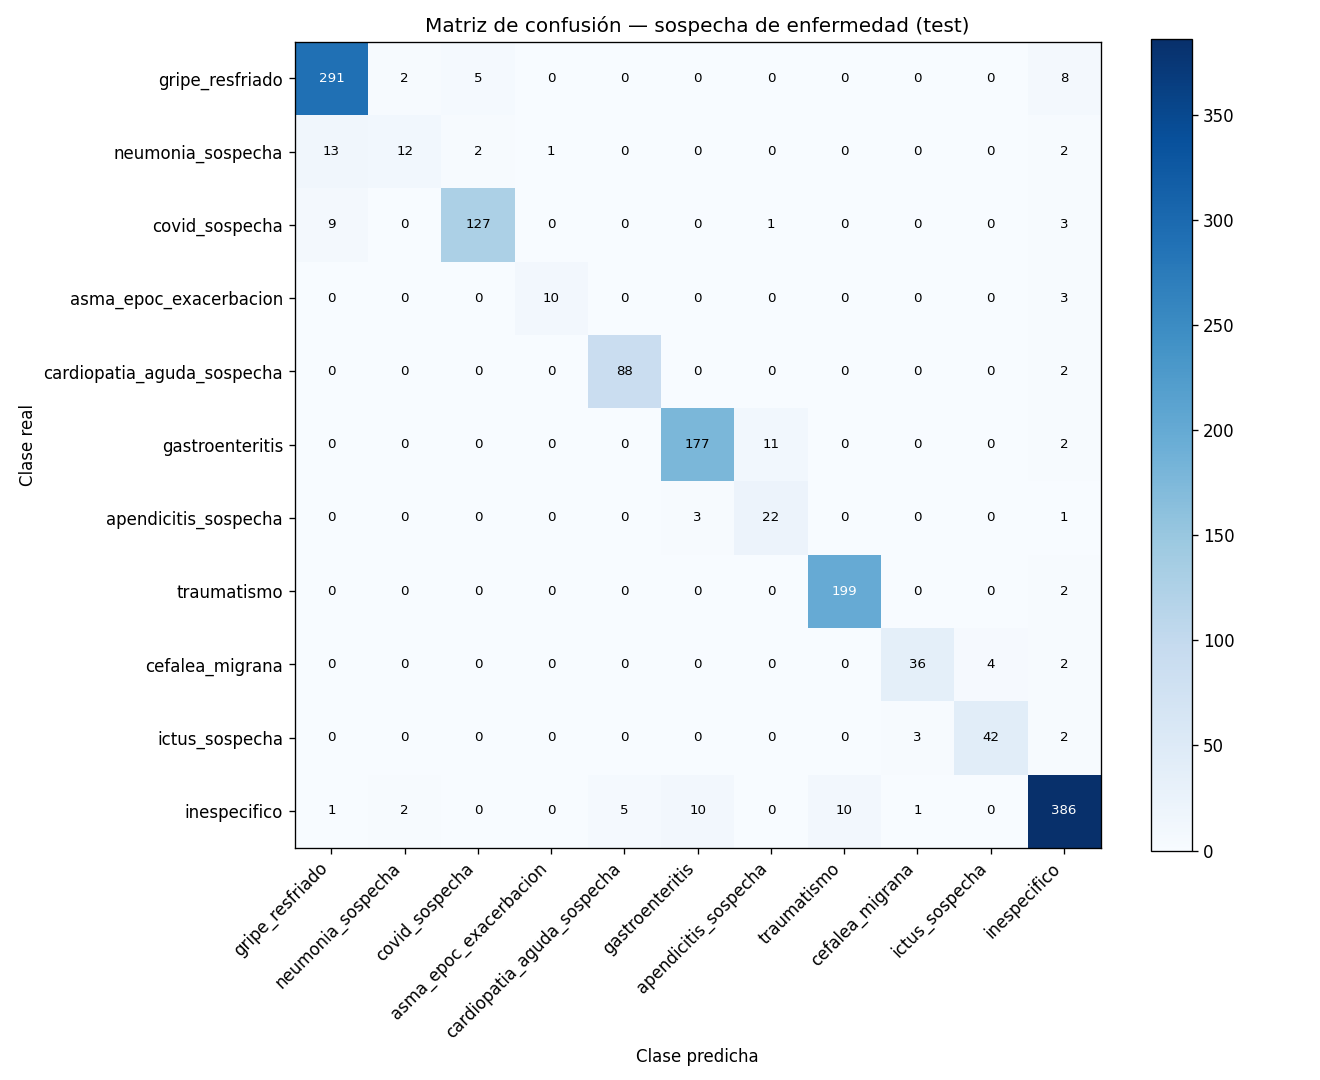

### Análisis crítico generado

# Análisis crítico — modelo de enfermedad `dis-20260514-8c9a3874`

**Fecha de evaluación**: 2026-05-14T15:32:16.381565+00:00

## 1. Resumen de rendimiento

- **Accuracy**: 0.9267
- **F1 macro**: 0.8665 *(media simple — sensible al desbalance de clases minoritarias)*
- **F1 weighted**: 0.9250 *(ponderada por soporte — más representativa del rendimiento global)*

## 2. Top 5 errores más frecuentes

| # | Real | Predicha | Casos |
|---|------|----------|-------|
| 1 | Sospecha de neumonía | Gripe / resfriado | 13 |
| 2 | Gastroenteritis | Sospecha de apendicitis | 11 |
| 3 | Cuadro inespecífico | Gastroenteritis | 10 |
| 4 | Cuadro inespecífico | Traumatismo | 10 |
| 5 | Sospecha de COVID-19 | Gripe / resfriado | 9 |

Los errores entre clases **clínicamente próximas** (gripe ↔ COVID, gastroenteritis ↔ apendicitis, cefalea ↔ ictus) son esperables — reflejan la matriz de proximidad clínica del ruido tipo A (DESIGN-08b §4.4). Los errores entre clases lejanas (p. ej. traumatismo → cardiopatia) son señal de problema y requieren revisión del generador o del entrenamiento.

## 3. F1 por clase (peor → mejor)

| Clase | F1 | Precisión | Recall | Soporte |
|-------|----|-----------|--------|---------|
| Sospecha de neumonía | 0.522 | 0.750 | 0.400 | 30 |
| Sospecha de apendicitis | 0.733 | 0.647 | 0.846 | 26 |
| Exacerbación asma/EPOC | 0.833 | 0.909 | 0.769 | 13 |
| Cefalea / migraña | 0.878 | 0.900 | 0.857 | 42 |
| Sospecha de ictus | 0.903 | 0.913 | 0.894 | 47 |
| Sospecha de COVID-19 | 0.927 | 0.948 | 0.907 | 140 |
| Gastroenteritis | 0.932 | 0.932 | 0.932 | 190 |
| Cuadro inespecífico | 0.932 | 0.935 | 0.930 | 415 |
| Gripe / resfriado | 0.939 | 0.927 | 0.951 | 306 |
| Sospecha cardiopatía aguda | 0.962 | 0.946 | 0.978 | 90 |
| Traumatismo | 0.971 | 0.952 | 0.990 | 201 |

Las clases minoritarias clínicas (neumonía, asma/EPOC, apendicitis) tienen soporte bajo — el F1 es ruidoso. `class_weight='balanced'` compensa parcialmente: trade-off entre recall en minoritarias (falsos positivos) vs precision en mayoritarias.

## 4. Comportamiento ante la variable espuria

`hora_envio` es una variable espuria (DESIGN-08 §4.3): se genera aleatoriamente y **no** aparece en ninguna regla del generador. Un modelo bien entrenado debe asignarle importancia muy baja.

- Importancia normalizada de `hora_envio`: **-0.0014** (ratio respecto a la feature más importante).

## 5. Top 5 features por importancia (permutation)

| # | Feature | Importancia |
|---|---------|-------------|
| 1 | `motivo_principal` | 0.6547 |
| 2 | `contacto_covid_reciente` | 0.1408 |
| 3 | `fiebre_subjetiva` | 0.0788 |
| 4 | `tos` | 0.0781 |
| 5 | `edad` | 0.0445 |

## 6. Limitación crítica (obligatoria)

Las etiquetas de enfermedad son **sintéticas**, generadas por reglas heurísticas que el equipo ha codificado a mano. El modelo aprende esas reglas con un 10 % de ruido — **no aprende patrones epidemiológicos reales**. Su uso clínico real está **explícitamente desautorizado**: la salida es una sospecha orientativa para apoyo administrativo (priorización de admisión), nunca un diagnóstico.

En un sistema real haría falta entrenamiento con historiales clínicos validados, supervisión médica continua, y certificación regulatoria (CE, FDA, AEMPS). El valor de este modelo es **pedagógico**: demuestra el flujo SDD → reglas → dataset → entrenamiento → evaluación → servicio HTTP con un segundo target sobre el mismo formulario, alineado con §3.1 ("predicción de enfermedades") y §7 (ética y limitaciones) del enunciado.

## 7. Desbalance de clases — discusión

La distribución de `disease_target` es naturalmente desbalanceada: `asma_epoc_exacerbacion` ~0.8 %, `neumonia_sospecha` ~1.5 % vs `inespecifico` ~30 % o `gripe_resfriado` ~20 %. Esto refleja frecuencias plausibles en un servicio de admisión real, no un defecto del generador (DESIGN-08b §4.3). Compensamos con `class_weight='balanced'` en el entrenamiento — alternativas consideradas y descartadas: oversampling SMOTE (introduce muestras sintéticas no clínicas), inflar artificialmente las features de entrada (rompe el realismo de la generación).


---

## `models\radiography\rx-efficientnetb0-20260515-2b92eec9`

,artefacto,existe
0,metadata.json,True
1,metrics.json,True
2,confusion_matrix.png,True
3,critical_analysis.md,True
4,model.pt / model.joblib,True


### Métricas principales

...

### Matriz de confusión numérica

,Pred: Sana,Pred: Neumonía,Pred: COVID-19
Real: Sana,145,4,1
Real: Neumonía,10,140,0
Real: COVID-19,1,2,147


### Errores principales fuera de la diagonal

,clase_real,clase_predicha,casos
2,Neumonía,Sana,10
0,Sana,Neumonía,4
5,COVID-19,Neumonía,2
1,Sana,COVID-19,1
4,COVID-19,Sana,1
3,Neumonía,COVID-19,0


### Matriz de confusión visual

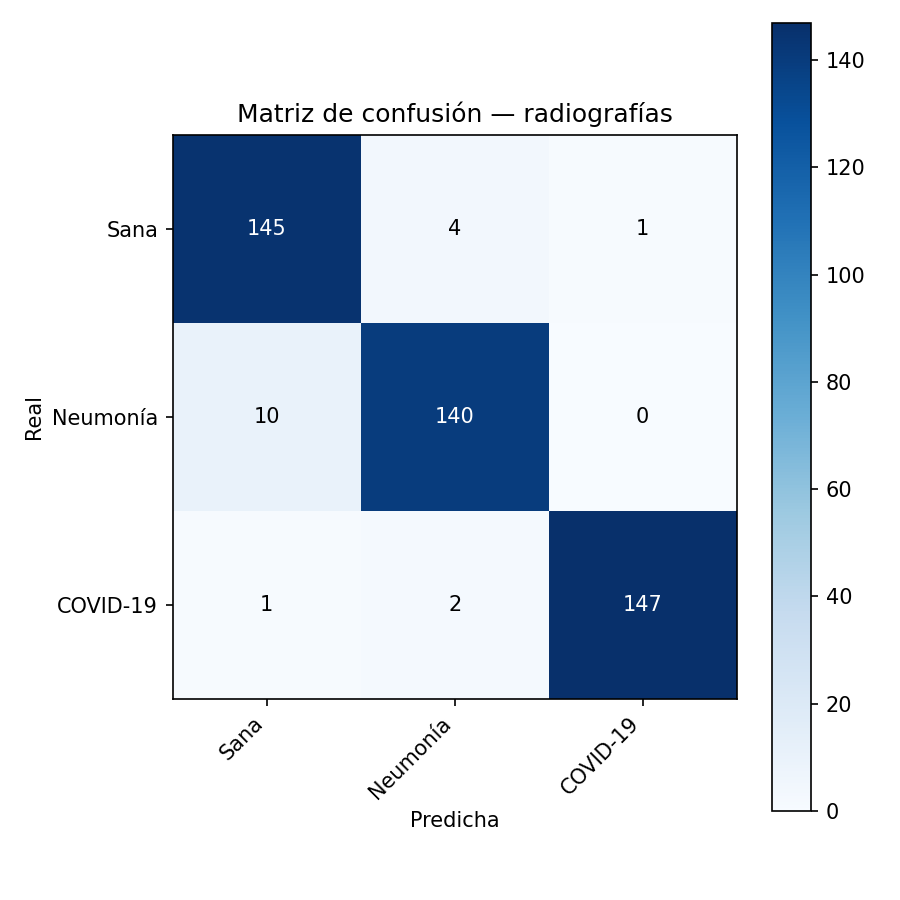

### Análisis crítico generado

# Análisis crítico del modelo de radiografías `rx-efficientnetb0-20260515-2b92eec9`

## 1. Resumen técnico

- **Backbone**: `efficientnet_b0`
- **Accuracy**: 0.9600
- **F1 macro**: 0.9601
- **Recall COVID-19**: 0.9800
- **Recall Neumonía**: 0.9333

## 2. Errores principales observados

| # | Clase real | Clase predicha | Casos |
|---|------------|----------------|-------|
| 1 | Neumonía | Sana | 10 |
| 2 | Sana | Neumonía | 4 |
| 3 | COVID-19 | Neumonía | 2 |
| 4 | Sana | COVID-19 | 1 |
| 5 | COVID-19 | Sana | 1 |

## 3. Impacto clínico de errores

### Falso negativo COVID-19

Una radiografía de COVID-19 clasificada como `Sana` o `Neumonía` tiene riesgo epidemiológico alto. Puede provocar falta de aislamiento, exposición del personal sanitario y contagios intrahospitalarios. Este es uno de los errores más graves del sistema.

### COVID-19 confundido con neumonía

El riesgo es medio-alto. Parte del manejo respiratorio puede ser similar, pero se pierde el componente epidemiológico: aislamiento, trazabilidad de contactos y protocolos COVID.

### Neumonía clasificada como sana

Implica retraso diagnóstico y terapéutico, especialmente problemático en pacientes vulnerables. Puede retrasar antibiótico, seguimiento o derivación.

### Sana clasificada como patológica

Es menos crítico que un falso negativo, pero genera sobrecarga asistencial, pruebas innecesarias, ansiedad del paciente y coste operativo.

## 4. Interpretación de sensibilidad

El recall COVID-19 (0.980) es razonable para un prototipo, aunque seguiría requiriendo validación clínica externa.

## 5. Limitaciones reales

- Dataset público con sesgos de adquisición, procedencia y calidad.
- No existe validación externa con datos hospitalarios propios.
- La clase `Neumonía` agrupa `Viral Pneumonia` y `Lung_Opacity`, simplificando una realidad clínica más compleja.
- El modelo puede aprender artefactos del dataset en lugar de patrones radiológicos generalizables.
- El sistema no sustituye criterio médico ni constituye dispositivo médico certificado.

## 6. Conclusión

El modelo es válido como módulo académico de Deep Learning integrado en una infraestructura Big Data hospitalaria. Para producción real harían falta más datos, validación multicéntrica, revisión radiológica experta, calibración de probabilidades y certificación regulatoria.

---

## `models\radiography\rx-resnet18-20260515-d397f8e5`

,artefacto,existe
0,metadata.json,True
1,metrics.json,True
2,confusion_matrix.png,True
3,critical_analysis.md,True
4,model.pt / model.joblib,True


### Métricas principales

...

### Matriz de confusión numérica

,Pred: Sana,Pred: Neumonía,Pred: COVID-19
Real: Sana,132,5,13
Real: Neumonía,21,125,4
Real: COVID-19,3,2,145


### Errores principales fuera de la diagonal

,clase_real,clase_predicha,casos
2,Neumonía,Sana,21
1,Sana,COVID-19,13
0,Sana,Neumonía,5
3,Neumonía,COVID-19,4
4,COVID-19,Sana,3
5,COVID-19,Neumonía,2


### Matriz de confusión visual

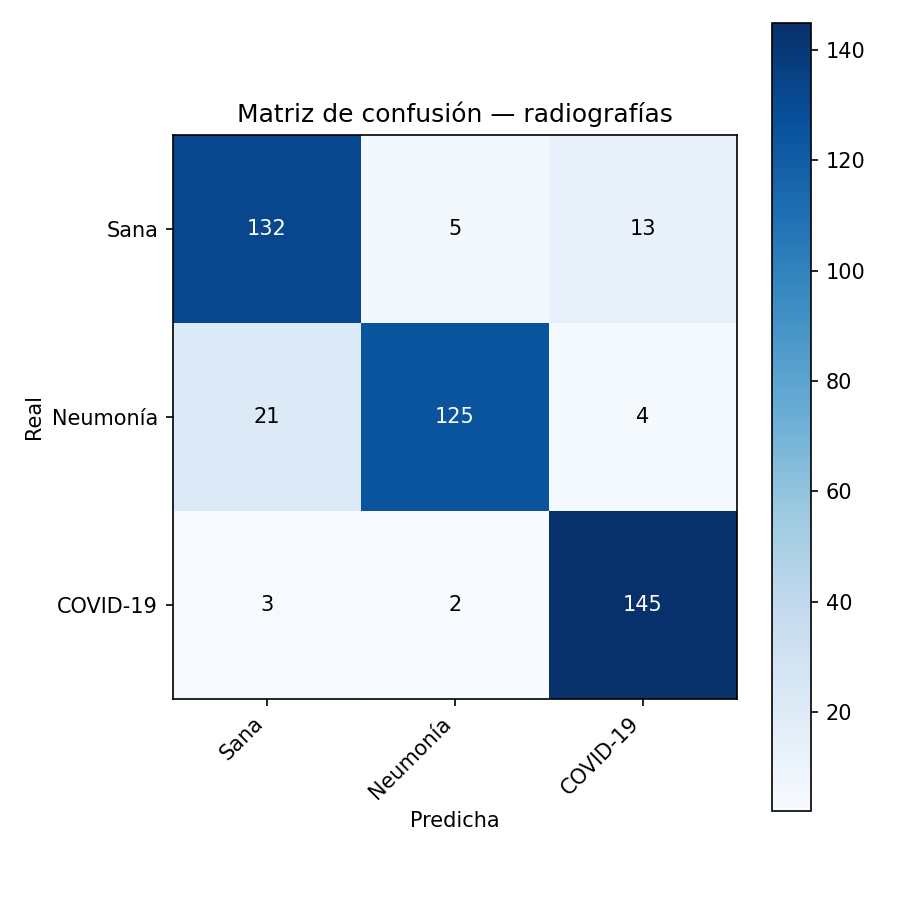

### Análisis crítico generado

# Análisis crítico del modelo de radiografías `rx-resnet18-20260515-d397f8e5`

## 1. Resumen técnico

- **Backbone**: `resnet18`
- **Accuracy**: 0.8933
- **F1 macro**: 0.8929
- **Recall COVID-19**: 0.9667
- **Recall Neumonía**: 0.8333

## 2. Errores principales observados

| # | Clase real | Clase predicha | Casos |
|---|------------|----------------|-------|
| 1 | Neumonía | Sana | 21 |
| 2 | Sana | COVID-19 | 13 |
| 3 | Sana | Neumonía | 5 |
| 4 | Neumonía | COVID-19 | 4 |
| 5 | COVID-19 | Sana | 3 |

## 3. Impacto clínico de errores

### Falso negativo COVID-19

Una radiografía de COVID-19 clasificada como `Sana` o `Neumonía` tiene riesgo epidemiológico alto. Puede provocar falta de aislamiento, exposición del personal sanitario y contagios intrahospitalarios. Este es uno de los errores más graves del sistema.

### COVID-19 confundido con neumonía

El riesgo es medio-alto. Parte del manejo respiratorio puede ser similar, pero se pierde el componente epidemiológico: aislamiento, trazabilidad de contactos y protocolos COVID.

### Neumonía clasificada como sana

Implica retraso diagnóstico y terapéutico, especialmente problemático en pacientes vulnerables. Puede retrasar antibiótico, seguimiento o derivación.

### Sana clasificada como patológica

Es menos crítico que un falso negativo, pero genera sobrecarga asistencial, pruebas innecesarias, ansiedad del paciente y coste operativo.

## 4. Interpretación de sensibilidad

El recall COVID-19 (0.967) es razonable para un prototipo, aunque seguiría requiriendo validación clínica externa.

## 5. Limitaciones reales

- Dataset público con sesgos de adquisición, procedencia y calidad.
- No existe validación externa con datos hospitalarios propios.
- La clase `Neumonía` agrupa `Viral Pneumonia` y `Lung_Opacity`, simplificando una realidad clínica más compleja.
- El modelo puede aprender artefactos del dataset en lugar de patrones radiológicos generalizables.
- El sistema no sustituye criterio médico ni constituye dispositivo médico certificado.

## 6. Conclusión

El modelo es válido como módulo académico de Deep Learning integrado en una infraestructura Big Data hospitalaria. Para producción real harían falta más datos, validación multicéntrica, revisión radiológica experta, calibración de probabilidades y certificación regulatoria.

---

## `models\radiography\rx-simplecnn-20260515-e8ac76f0`

,artefacto,existe
0,metadata.json,True
1,metrics.json,True
2,confusion_matrix.png,True
3,critical_analysis.md,True
4,model.pt / model.joblib,True


### Métricas principales

...

### Matriz de confusión numérica

,Pred: Sana,Pred: Neumonía,Pred: COVID-19
Real: Sana,95,21,34
Real: Neumonía,16,116,18
Real: COVID-19,21,24,105


### Errores principales fuera de la diagonal

,clase_real,clase_predicha,casos
1,Sana,COVID-19,34
5,COVID-19,Neumonía,24
0,Sana,Neumonía,21
4,COVID-19,Sana,21
3,Neumonía,COVID-19,18
2,Neumonía,Sana,16


### Matriz de confusión visual

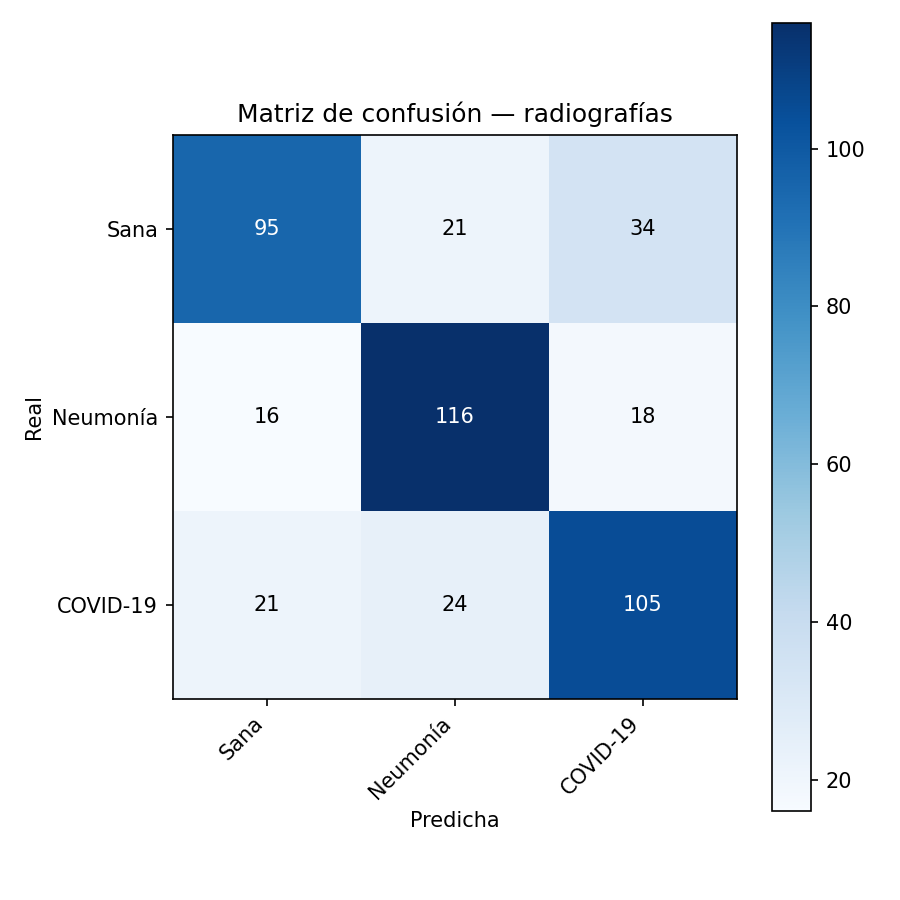

### Análisis crítico generado

# Análisis crítico del modelo de radiografías `rx-simplecnn-20260515-e8ac76f0`

## 1. Resumen técnico

- **Backbone**: `simple_cnn`
- **Accuracy**: 0.7022
- **F1 macro**: 0.7013
- **Recall COVID-19**: 0.7000
- **Recall Neumonía**: 0.7733

## 2. Errores principales observados

| # | Clase real | Clase predicha | Casos |
|---|------------|----------------|-------|
| 1 | Sana | COVID-19 | 34 |
| 2 | COVID-19 | Neumonía | 24 |
| 3 | Sana | Neumonía | 21 |
| 4 | COVID-19 | Sana | 21 |
| 5 | Neumonía | COVID-19 | 18 |

## 3. Impacto clínico de errores

### Falso negativo COVID-19

Una radiografía de COVID-19 clasificada como `Sana` o `Neumonía` tiene riesgo epidemiológico alto. Puede provocar falta de aislamiento, exposición del personal sanitario y contagios intrahospitalarios. Este es uno de los errores más graves del sistema.

### COVID-19 confundido con neumonía

El riesgo es medio-alto. Parte del manejo respiratorio puede ser similar, pero se pierde el componente epidemiológico: aislamiento, trazabilidad de contactos y protocolos COVID.

### Neumonía clasificada como sana

Implica retraso diagnóstico y terapéutico, especialmente problemático en pacientes vulnerables. Puede retrasar antibiótico, seguimiento o derivación.

### Sana clasificada como patológica

Es menos crítico que un falso negativo, pero genera sobrecarga asistencial, pruebas innecesarias, ansiedad del paciente y coste operativo.

## 4. Interpretación de sensibilidad

El recall COVID-19 (0.700) es insuficiente para uso clínico real. El modelo puede servir como demostrador académico, pero no como herramienta autónoma de cribado.

## 5. Limitaciones reales

- Dataset público con sesgos de adquisición, procedencia y calidad.
- No existe validación externa con datos hospitalarios propios.
- La clase `Neumonía` agrupa `Viral Pneumonia` y `Lung_Opacity`, simplificando una realidad clínica más compleja.
- El modelo puede aprender artefactos del dataset en lugar de patrones radiológicos generalizables.
- El sistema no sustituye criterio médico ni constituye dispositivo médico certificado.

## 6. Conclusión

El modelo es válido como módulo académico de Deep Learning integrado en una infraestructura Big Data hospitalaria. Para producción real harían falta más datos, validación multicéntrica, revisión radiológica experta, calibración de probabilidades y certificación regulatoria.

---

## `models\triage\tri-20260514-60eff3c2`

,artefacto,existe
0,metadata.json,True
1,metrics.json,True
2,confusion_matrix.png,True
3,critical_analysis.md,True
4,model.pt / model.joblib,True


### Métricas principales

...

### Matriz de confusión numérica

,Pred: Alta,Pred: Media,Pred: Baja
Real: Alta,223,48,7
Real: Media,18,911,13
Real: Baja,1,36,243


### Errores principales fuera de la diagonal

,clase_real,clase_predicha,casos
0,Alta,Media,48
5,Baja,Media,36
2,Media,Alta,18
3,Media,Baja,13
1,Alta,Baja,7
4,Baja,Alta,1


### Matriz de confusión visual

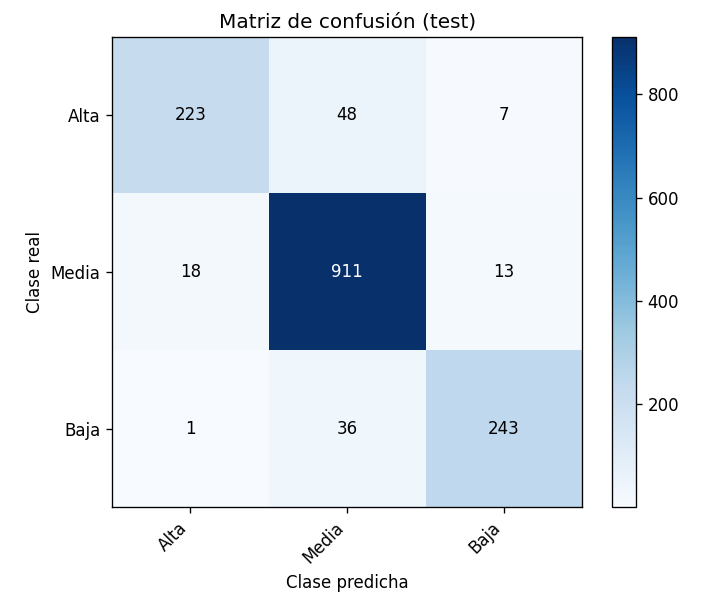

### Análisis crítico generado

# Análisis crítico — modelo de triaje `tri-20260514-60eff3c2`

**Fecha de evaluación**: 2026-05-14T15:32:01.775256+00:00

## 1. Resumen de rendimiento

- **Accuracy**: 0.9180
- **F1 macro**: 0.8978
- **Recall clase Alta**: 0.8022 *(métrica clínicamente crítica — falsos negativos de Alta son el peor escenario)*

## 2. Error más frecuente

El error más frecuente en la matriz de confusión es **Alta → Media** con **48 casos** sobre 1500 registros de test.

**Impacto clínico**: Un paciente urgente fue clasificado como moderado. Retraso potencial en su atención, con riesgo clínico si se trata de patología tiempo-dependiente.

## 3. Comportamiento ante la variable espuria

`hora_envio` es una variable espuria (ver DESIGN-08 §4.3): se genera aleatoriamente en el dataset sintético y **no** está presente en ninguna regla clínica. Un modelo bien entrenado debería asignarle importancia **muy baja**.

- Importancia normalizada de `hora_envio`: **0.0095** (ratio respecto a la feature más importante).

> ⚠️ **Aviso**: `hora_envio` tiene importancia superior al umbral (0.0050). Esto sugiere que el generador sintético ha introducido alguna correlación accidental con el target. Revisar `generate_dataset.py` antes de defender resultados.

## 4. Top 5 features por importancia (permutation)

| # | Feature | Importancia (permutation) |
|---|---------|---------------------------|
| 1 | `dificultad_respiratoria_subjetiva` | 0.1749 |
| 2 | `edad` | 0.1619 |
| 3 | `fiebre_subjetiva` | 0.1371 |
| 4 | `motivo_principal` | 0.0942 |
| 5 | `intensidad_dolor` | 0.0903 |

## 5. Limitación fundamental

El dataset es **sintético** y sus etiquetas vienen de reglas que el propio equipo ha codificado, más un **10 % de ruido** deliberado (ver DESIGN-08 §4.4, §4.5). El modelo, por construcción, reproduce esas reglas; sus métricas **no reflejan utilidad clínica real**.

Su valor es **pedagógico**: demuestra que el flujo SDD → dataset → entrenamiento → evaluación → servicio HTTP funciona end-to-end, con trazabilidad, reproducibilidad y análisis crítico alineados con el enunciado §3.1 y §7.

En un despliegue clínico real, este modelo **no sustituye** al juicio del personal sanitario ni constituye un dispositivo médico validado.


In [10]:
# Matrices de confusión + métricas + análisis crítico
# Celda robusta: funciona aunque confusion_matrix sea lista, dict o lista de dicts.

from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image, Markdown


def read_json_safe(path: Path) -> dict:
    path = Path(path)
    if not path.exists():
        return {}
    try:
        return json.loads(path.read_text(encoding="utf-8"))
    except Exception as exc:
        return {"_error": str(exc)}


def read_text_safe(path: Path) -> str:
    path = Path(path)
    if not path.exists():
        return ""
    return path.read_text(encoding="utf-8", errors="ignore")


def get_class_names(metadata: dict, metrics: dict, artifact_name: str) -> list[str]:
    """Intenta inferir etiquetas de clase para mostrar la matriz."""
    for key in ["class_names", "classes", "labels"]:
        if key in metadata and isinstance(metadata[key], list):
            return metadata[key]
        if key in metrics and isinstance(metrics[key], list):
            return metrics[key]

    lower = artifact_name.lower()

    if "tri" in lower or "triage" in lower:
        return ["Alta", "Media", "Baja"]

    if "dis" in lower or "disease" in lower:
        return [
            "gripe_resfriado",
            "neumonia_sospecha",
            "covid_sospecha",
            "asma_epoc_exacerbacion",
            "cardiopatia_aguda_sospecha",
            "gastroenteritis",
            "apendicitis_sospecha",
            "traumatismo",
            "cefalea_migrana",
            "ictus_sospecha",
            "inespecifico",
        ]

    if "rx" in lower or "radio" in lower or "efficientnet" in lower or "resnet" in lower or "simplecnn" in lower:
        return ["Sana", "Neumonía", "COVID-19"]

    return []


def normalize_confusion_matrix(raw_cm, labels: list[str]) -> tuple[list[list[int]] | None, list[str]]:
    """
    Convierte confusion_matrix a lista de listas.
    Soporta:
    - [[...], [...]]
    - {"matrix": [[...]]}
    - {"Clase A": {"Clase A": 10, "Clase B": 2}, ...}
    - {"Clase A": [10, 2, 0], ...}
    - [{"Clase A": 10, "Clase B": 2}, ...]
    """
    if raw_cm is None:
        return None, labels

    # Caso dict con campo interno
    if isinstance(raw_cm, dict):
        for inner_key in ["matrix", "values", "data", "confusion_matrix"]:
            if inner_key in raw_cm:
                return normalize_confusion_matrix(raw_cm[inner_key], labels)

        row_labels = list(raw_cm.keys())

        # Dict de dicts: {"real": {"pred": count}}
        if all(isinstance(v, dict) for v in raw_cm.values()):
            if labels and len(labels) == len(row_labels):
                col_labels = labels
            else:
                col_labels = row_labels

            matrix = [
                [int(raw_cm.get(r, {}).get(c, 0)) for c in col_labels]
                for r in row_labels
            ]

            # Si las claves reales son los nombres de clase, usarlas como labels
            if len(row_labels) == len(matrix):
                labels = row_labels

            return matrix, labels

        # Dict de listas: {"real": [..]}
        if all(isinstance(v, (list, tuple)) for v in raw_cm.values()):
            matrix = [list(v) for v in raw_cm.values()]
            labels = row_labels if len(row_labels) == len(matrix) else labels
            return matrix, labels

        return None, labels

    # Lista de dicts: [{"A": 1, "B": 2}, ...]
    if isinstance(raw_cm, list) and raw_cm and all(isinstance(row, dict) for row in raw_cm):
        if labels and len(labels) == len(raw_cm):
            col_labels = labels
        else:
            col_labels = list(raw_cm[0].keys())

        matrix = [
            [int(row.get(c, 0)) for c in col_labels]
            for row in raw_cm
        ]

        labels = col_labels if len(col_labels) == len(matrix) else [f"Clase {i}" for i in range(len(matrix))]
        return matrix, labels

    # Lista de listas normal
    if isinstance(raw_cm, list):
        matrix = []
        for row in raw_cm:
            if isinstance(row, (list, tuple)):
                matrix.append([int(x) for x in row])
            else:
                return None, labels

        if not labels or len(labels) != len(matrix):
            labels = [f"Clase {i}" for i in range(len(matrix))]

        return matrix, labels

    return None, labels


def show_artifact_confusion(artifact_dir: Path) -> None:
    artifact_dir = Path(artifact_dir)

    metadata_path = artifact_dir / "metadata.json"
    metrics_path = artifact_dir / "metrics.json"
    cm_png_path = artifact_dir / "confusion_matrix.png"
    critical_path = artifact_dir / "critical_analysis.md"

    metadata = read_json_safe(metadata_path)
    metrics = read_json_safe(metrics_path)

    display(Markdown(f"---\n\n## `{artifact_dir.relative_to(ROOT)}`"))

    # Estado de artefactos
    artifact_status = pd.DataFrame([
        {"artefacto": "metadata.json", "existe": metadata_path.exists()},
        {"artefacto": "metrics.json", "existe": metrics_path.exists()},
        {"artefacto": "confusion_matrix.png", "existe": cm_png_path.exists()},
        {"artefacto": "critical_analysis.md", "existe": critical_path.exists()},
        {
            "artefacto": "model.pt / model.joblib",
            "existe": (artifact_dir / "model.pt").exists() or (artifact_dir / "model.joblib").exists(),
        },
    ])
    display(artifact_status)

    # Métricas principales
    metric_keys = [
        "accuracy",
        "f1_macro",
        "f1_weighted",
        "recall_covid",
        "recall_neumonia",
    ]

    metric_rows = []
    for key in metric_keys:
        if key in metrics:
            metric_rows.append({"métrica": key, "valor": metrics[key]})

    if metric_rows:
        display(Markdown("### Métricas principales"))
        display(pd.DataFrame(metric_rows))

    # Métricas por clase
    if isinstance(metrics.get("per_class"), dict):
        display(Markdown("### Métricas por clase"))
        display(pd.DataFrame(metrics["per_class"]).T)

    # Matriz de confusión desde metrics.json
    raw_cm = metrics.get("confusion_matrix")
    labels_guess = get_class_names(metadata, metrics, artifact_dir.name)
    cm, labels = normalize_confusion_matrix(raw_cm, labels_guess)

    if cm is not None:
        n = len(cm)

        if not labels or len(labels) != n:
            labels = [f"Clase {i}" for i in range(n)]

        cm_df = pd.DataFrame(
            cm,
            index=[f"Real: {label}" for label in labels],
            columns=[f"Pred: {label}" for label in labels],
        )

        display(Markdown("### Matriz de confusión numérica"))
        display(cm_df)

        errors = []
        for i in range(n):
            for j in range(n):
                if i != j:
                    errors.append({
                        "clase_real": labels[i],
                        "clase_predicha": labels[j],
                        "casos": cm[i][j],
                    })

        errors_df = pd.DataFrame(errors).sort_values("casos", ascending=False)

        display(Markdown("### Errores principales fuera de la diagonal"))
        display(errors_df.head(10))

    else:
        display(Markdown("### Matriz de confusión numérica"))
        display(Markdown("No se pudo leer `confusion_matrix` desde `metrics.json` o no existe."))

    # Imagen de matriz de confusión
    if cm_png_path.exists():
        display(Markdown("### Matriz de confusión visual"))
        display(Image(filename=str(cm_png_path)))

    # Critical analysis
    if critical_path.exists():
        display(Markdown("### Análisis crítico generado"))
        display(Markdown(read_text_safe(critical_path)))


# ---------------------------------------------------------------------
# Artefactos a mostrar
# ---------------------------------------------------------------------

artifact_dirs = []

for folder in [
    ROOT / "models" / "triage",
    ROOT / "models" / "disease",
]:
    if folder.exists():
        artifact_dirs.extend([p for p in folder.iterdir() if p.is_dir()])

radio_root = ROOT / "models" / "radiography"
if radio_root.exists():
    artifact_dirs.extend([
        p for p in radio_root.iterdir()
        if p.is_dir() and p.name.startswith("rx-")
    ])

display(Markdown("# Matrices de confusión, métricas y análisis crítico"))

if not artifact_dirs:
    display(Markdown("No se han encontrado artefactos con modelos en `models/`."))
else:
    for artifact_dir in sorted(artifact_dirs):
        show_artifact_confusion(artifact_dir)